In [35]:
%pip install -r ../requirements.txt


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
import copernicusmarine
from datetime import timedelta
from datetime import datetime
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import xarray as xr


In [37]:
copernicusmarine.login(
    username = "sng",
    password = "Copernicus1!",
)

INFO - 2026-09-24T21:18:34Z - Using existing credentials from C:\Users\syng8\.copernicusmarine\.copernicusmarine-credentials. Use --force-overwrite combined with credentials (specified by arguments, netrc file or environment variables) to always overwrite.


True

Data Loading

In [38]:
import pandas as pd

# Show all columns without truncation
pd.set_option('display.max_columns', None)

# Show full text/content inside each cell without clipping
pd.set_option('display.max_colwidth', None)

hae_url = "https://raw.githubusercontent.com/Break-Through-Tech/Oregon-State-University-1A-forecasting-risk-of-harmful-algal-blooms-in-coastal-marine-ecosystems/main/data/raw/harmful_algae_events.csv"

HAE_data = pd.read_csv(hae_url)

HAE_data.head()

C:\Users\syng8\AppData\Local\Temp\ipykernel_29392\2061439656.py:11: DtypeWarning: Columns (6: Submitter, 19: Original Grid Code, 48: Unexplained Toxicity, 62: Additional Algae Info) have mixed types. Specify dtype option on import or set low_memory=False.
  HAE_data = pd.read_csv(hae_url)


,Event ID,Event Name,Year,Country,Region,Status,Submitter,Created At,Updated At,Event Date,Start Date,End Date,Date Comments,Quarantine Start,Quarantine End,Additional Date Info,Latitude,Longitude,Location Description,Original Grid Code,Monitoring Grids,Additional Location Info,Monitoring Programme?,Programme Name,Occurred Before?,Occurred Before Details,Water Discoloration,High Phytoplankton,Seafood Toxin,Mass Mortality,Foam/Mucilage,Freshwater,Other Effect,Other Effect Details,Humans Affected,Natural Fish Affected,Aquaculture Fish Affected,Shellfish Affected,Birds Affected,Marine Mammals Affected,Plankton Affected,Benthic Life Affected,Seaweed Affected,Other Terrestrial Affected,Impact Comments,Terrestrial Comments,Toxin Detected?,Toxicity Range,Unexplained Toxicity,Toxicity Comments,Transvectors,Causative Species,Causative Species Details,Associated Species,Associated Species Details,Syndromes,Toxins Found,Assay Species Tested,Assay Toxins,Assay Concentrations,Assay Methods,Chlorophyll Analysis,Additional Algae Info,Weather Conditions,Wind Direction,Wind Velocity,Water Temp,Salinity,Oxygen Content,Oxygen Saturation,Turbidity,Secchi Disc,Current Velocity,Advected?,In Situ?,Advected Info,Stratification Info,Nutrients,Additional Env Info,Additional Harmful Effect Info,Additional Bloom Info,Management Decision,Economic Losses,References,Contacts
0,14822,NO-26-015,2026,NORWAY,Region 12 (EUR),Submitted,mona.ring.kleiven@hi.no,2026-06-22,2026-06-22,NaN,2026-05-04,2026-06-01,NaN,NaN,NaN,NaN,58.276080,5.547250,"Nordasundet, Egersund",NaN,NO-10,NaN,No,NaN,NaN,NaN,No,Yes,No,No,No,No,No,NaN,No,No,No,Yes,No,No,No,No,No,No,NaN,NaN,Yes,No,No,NaN,NaN,Alexandrium,Alexandrium [200 cells/L] (week 19 and 21),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Harvesting was locally banned. The public was warned against picking toxic mussels.,Unknown,NaN,Mona Ring Kleiven
1,14819,NO-26-012,2026,NORWAY,Region 12 (EUR),Submitted,mona.ring.kleiven@hi.no,2026-06-22,2026-06-22,NaN,2026-04-20,2026-06-01,NaN,NaN,NaN,NaN,60.517717,4.890717,"Ulvsundet, Øygården",NaN,NO-10,NaN,No,NaN,NaN,NaN,No,No,Yes,No,No,No,No,NaN,No,No,No,Yes,No,No,No,No,No,No,NaN,NaN,Yes,1260-645 µg/kg,Yes,Week21,Mytulis edulis,NaN,NaN,NaN,NaN,PSP,NaN,Alexandrium,STX eq,1260 µg/kg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Harvesting was locally banned. The public was warned against picking toxic mussels.,Unknown,NaN,Mona Ring Kleiven
2,14810,NO-26-003,2026,NORWAY,Region 12 (EUR),Submitted,mona.ring.kleiven@hi.no,2026-05-18,2026-05-18,NaN,2026-04-20,2026-05-04,NaN,NaN,NaN,Peak 23 th of April,58.424515,8.756882,"Flødevigen, Arendal, Agder.",NaN,NO-11,NaN,No,NaN,NaN,NaN,No,Yes,No,No,No,No,No,NaN,No,No,Yes,No,No,No,No,No,No,No,NaN,NaN,No,No,No,NaN,NaN,Chrysochromulina,Chrysochromulina [2378273 cells/L] (23.4.26),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0-3 m,NaN,NaN,NaN,NaN,NaN,Fish farms warned,NaN,NaN,Mona Ring Kleiven
3,14821,NO-26-014,2026,NORWAY,Region 12 (EUR),Submitted,mona.ring.kleiven@hi.no,2026-06-22,2026-06-22,NaN,2026-04-20,2026-06-15,NaN,NaN,NaN,NaN,62.503620,6.474960,"Mørkesetsundet, Ålesund",NaN,NO-08,NaN,No,NaN,NaN,NaN,No,No,Yes,No,No,No,No,NaN,No,No,No,Yes,No,No,No,No,No,No,NaN,NaN,Yes,PSP: 929-505 µg/kg/ AZP: 3267 µg/kg,Yes,NaN,Mytulis edulis,NaN,NaN,NaN,NaN,PSP; AZP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Harvesting was locally banned. The public was warned against picking toxic mussels.,Unknown,NaN,Mona Ring Kleiven
4,14812,NO-26-005,2026,NORWAY,Region 12 (EUR),Submitted,mona.ring.kleiven@hi.no,2026-06-22,2026-06-22,2026-04-06,NaN,NaN,NaN,2026-04-20,2026-06-15,Alexandrium spp from week 15.,59.150000,10.690000,"Djupeklo, Fredrikstad",NaN,NO-14,NaN,No,NaN,NaN,NaN,No,Yes,Yes,No,No,No,No,NaN,No,No,No,Yes,No,No,No,No,No,No,NaN,NaN,Yes,945-696 µg/kg,No,NaN,Mytulis edu

Addressing Missing Values & Outliers

In [39]:
df = pd.DataFrame(HAE_data)

# Missing Summary
missing_summary = pd.DataFrame({
    "missing_amt": df.isna().sum(),
    "missing_pct": df.isna().mean()
})
missing_summary

,missing_amt,missing_pct
Event ID,0,0.000000
Event Name,0,0.000000
Year,0,0.000000
Country,0,0.000000
Region,13856,0.982625
...,...,...
Additional Bloom Info,13932,0.988015
Management Decision,10152,0.719949
Economic Losses,13286,0.942203
References,11947,0.847245


In [40]:
numeric_df = df.select_dtypes(include="number")

basic_statistics = numeric_df.agg(["mean", "std", "min", "max"]).T

basic_statistics


,mean,std,min,max
Event ID,7628.603503,4245.972102,1.000000,14822.000000
Year,2008.732147,10.346621,1770.000000,2026.000000
Latitude,20.092402,30.729130,-78.383333,82.233333
Longitude,-31.902127,99.148047,-808.868400,177.288889
Terrestrial Comments,NaN,NaN,NaN,NaN
Toxins Found,NaN,NaN,NaN,NaN
Chlorophyll Analysis,8.420000,NaN,8.420000,8.420000
Stratification Info,0.118885,0.323745,0.000000,1.000000
Nutrients,NaN,NaN,NaN,NaN


In [41]:
print("Duplicate rows:", df.duplicated().sum()) #There are no duplicates
df.describe(include = "all")

Duplicate rows: 0


,Event ID,Event Name,Year,Country,Region,Status,Submitter,Created At,Updated At,Event Date,Start Date,End Date,Date Comments,Quarantine Start,Quarantine End,Additional Date Info,Latitude,Longitude,Location Description,Original Grid Code,Monitoring Grids,Additional Location Info,Monitoring Programme?,Programme Name,Occurred Before?,Occurred Before Details,Water Discoloration,High Phytoplankton,Seafood Toxin,Mass Mortality,Foam/Mucilage,Freshwater,Other Effect,Other Effect Details,Humans Affected,Natural Fish Affected,Aquaculture Fish Affected,Shellfish Affected,Birds Affected,Marine Mammals Affected,Plankton Affected,Benthic Life Affected,Seaweed Affected,Other Terrestrial Affected,Impact Comments,Terrestrial Comments,Toxin Detected?,Toxicity Range,Unexplained Toxicity,Toxicity Comments,Transvectors,Causative Species,Causative Species Details,Associated Species,Associated Species Details,Syndromes,Toxins Found,Assay Species Tested,Assay Toxins,Assay Concentrations,Assay Methods,Chlorophyll Analysis,Additional Algae Info,Weather Conditions,Wind Direction,Wind Velocity,Water Temp,Salinity,Oxygen Content,Oxygen Saturation,Turbidity,Secchi Disc,Current Velocity,Advected?,In Situ?,Advected Info,Stratification Info,Nutrients,Additional Env Info,Additional Harmful Effect Info,Additional Bloom Info,Management Decision,Economic Losses,References,Contacts
count,14101.000000,14101,14101.000000,14101,245,14101,17,10819,3188,7761,3856,3403,1969,2593,2280,1974,14044.000000,14044.000000,13410,929,13706,2599,14101,11010,14084,2327,14101,14101,14101,14101,14101,14101,14101,186,14101,14101,14101,14101,14101,14101,14101,14101,14101,14101,878,0.0,14101,4472,3392.0,210,5260,7859,7859,952,952,11587,0.0,3455,2249,1351,3285,1.00,3,267,14081,124,665,506,168,79,87,143,1855,14082,14082,835,1758.000000,0.0,596,1764,169,3949,815,2154,13801
unique,NaN,14101,NaN,106,15,2,3,1043,482,4650,2545,2377,1628,1825,1642,1632,NaN,NaN,4604,97,619,1878,2,764,1,1359,2,2,2,2,2,2,2,124,2,2,2,2,2,2,2,2,2,2,575,NaN,2,2508,6.0,97,651,911,4205,404,708,33,NaN,891,101,1244,43,NaN,3,119,16,101,405,336,156,70,68,107,6,2,2,335,NaN,NaN,455,1101,163,1337,545,1183,540
top,NaN,NO-26-015,NaN,FRENCH POLYNESIA,Region 12 (EUR),Approved,mona.ring.kleiven@hi.no,2018-09-27,2019-12-03,2020-11-27,1995-01-01,2005-12-31,http://www.intecmar.gal/,2018-01-01,2011-12-31,http://www.intecmar.gal/,NaN,NaN,TAHITI Island,PT-03,PF-TUAM,http://www.intecmar.gal/,Yes,CFP monitoring programme of French Polynesia,No,several times,No,No,Yes,No,No,No,No,Isolated strains from HABs,No,No,No,No,No,No,No,No,No,No,No human intoxication occurred,NaN,No,60 ug per 100g,0.0,Lipophylic toxins,Mytilus edulis,Pyrodinium bahamense,Pyrodinium bahamense,Cylindrospermopsis raciborskii Seenaya et Subba Raju 1972,Cylindrospermopsis raciborskii Seenaya et Subba Raju 1972,CFP (Ciguatera Fish Poisoning),NaN,Mytilus edulis,STX eq,Positive,Bioassay-Mouse,NaN,Round and oval forms,"warm, calm",,3,18,32,6,100,2.5,3.5,0,No,No,Sampling aprox 0-3 meters,NaN,NaN,Sampling aprox 0-3 meters,http://www.intecmar.gal/Informacion/biotoxinas/Evolucion/Default.aspx?sm=a6,A slight halocline was observed,Harvesting was locally banned. The public was warned against picking toxic mussels.,Mussel plants were banned from harvesting.,More details in China Disaster Bulletin,"GATTI, Clémence"
freq,NaN,1,NaN,3968,63,14084,15,154,179,38,14,14,50,13,13,50,NaN,NaN,260,47,1574,45,12133,3810,14084,63,12436,10787,10351,13251,13996,13634,13928,10,9499,13382,13589,9198,14044,14002,13725,13912,14040,14038,84,NaN,7696,481,2285.0,37,509,806,753,117,117,4017,NaN,681,553,9,1641,NaN,1,37,13969,4,18,23,3,4,6,7,1846,13504,13063,146,NaN,NaN,39,145,3,459,59,116,3964
mean,7628.603503,NaN,2008.732147,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.092402,-31.902127,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [42]:
pd.set_option('display.max_rows', 20)
HAE_data[
    HAE_data["Event Date"].isna()
][["Region", "Event Date", "Start Date", "End Date"]]

,Region,Event Date,Start Date,End Date
0,Region 12 (EUR),NaN,2026-05-04,2026-06-01
1,Region 12 (EUR),NaN,2026-04-20,2026-06-01
2,Region 12 (EUR),NaN,2026-04-20,2026-05-04
3,Region 12 (EUR),NaN,2026-04-20,2026-06-15
5,Region 12 (EUR),NaN,2026-04-06,2026-05-18
...,...,...,...,...
14091,NaN,NaN,1936-01-01,1936-01-31
14092,NaN,NaN,1916-11-01,1916-12-31
14093,NaN,NaN,1910-11-01,1911-01-31
14096,NaN,NaN,1901-01-01,1901-01-31


Dropping rows that have empty dates or latitude/longitude


In [43]:
HAE_clean = HAE_data.copy()

# Convert invalid date values to NaT before filtering rows.
for col in ["Event Date", "Start Date", "End Date"]:
    HAE_clean[col] = pd.to_datetime(HAE_clean[col], errors="coerce")

no_lat_lon_mask = (
    HAE_clean["Latitude"].isna() |
    HAE_clean["Longitude"].isna()
 )

no_date_mask = HAE_clean[
    ["Event Date", "Start Date", "End Date"]
].isna().all(axis=1)

print("Rows with no temporal information:", no_date_mask.sum())
print("Rows with no spatial information:", no_lat_lon_mask.sum())

HAE_clean = HAE_clean[~no_date_mask].copy()
HAE_clean = HAE_clean.dropna(subset=["Latitude", "Longitude"]).copy()

print("Original rows:", len(HAE_data))
print("Cleaned rows:", len(HAE_clean))

Rows with no temporal information: 3836
Rows with no spatial information: 57
Original rows: 14101
Cleaned rows: 10243


Putting a Target Date for Data
Rule 1: If Start Date is empty, BUT both Event Date & End Date exist -> Pick Middle of Event and End
Rule 2: If Start Date and End Date exist -> Pick Middle of Start and End
Rule 3: If Start Date is empty -> Fallback to Event Date
Rule 4: If Event Date is empty -> Fallback to Start Date

In [44]:
empty_event_date = HAE_clean["Event Date"].isna().sum()
empty_start_date = HAE_clean["Start Date"].isna().sum()
empty_end_date = HAE_clean["End Date"].isna().sum()

print("Rows with empty Event Date:", empty_event_date)
print("Rows with empty Start Date:", empty_start_date)
print("Rows with empty End Date:", empty_end_date)

Rows with empty Event Date: 2503
Rows with empty Start Date: 6394
Rows with empty End Date: 6847


In [45]:
# Date columns were parsed during the cleaning step.

midpoint_date = HAE_clean["Start Date"] + (HAE_clean["End Date"] - HAE_clean["Start Date"]) / 2

# Build Target_Date in rule order without requiring a later numpy import.
HAE_clean["Target_Date"] = HAE_clean["End Date"].copy()
HAE_clean["Date_Derivation_Method"] = "used_end_date"

condition = (
    HAE_clean["Start Date"].isna()
    & HAE_clean["Event Date"].notna()
    & HAE_clean["End Date"].notna()
)
HAE_clean.loc[condition, "Target_Date"] = (
    HAE_clean.loc[condition, "Event Date"]
    + (HAE_clean.loc[condition, "End Date"] - HAE_clean.loc[condition, "Event Date"]) / 2
 )
HAE_clean.loc[condition, "Date_Derivation_Method"] = "midpoint_event_end"

condition = HAE_clean["Start Date"].notna() & HAE_clean["End Date"].notna()
HAE_clean.loc[condition, "Target_Date"] = midpoint_date.loc[condition]
HAE_clean.loc[condition, "Date_Derivation_Method"] = "midpoint_start_end"

condition = HAE_clean["Start Date"].isna() & HAE_clean["Event Date"].notna()
HAE_clean.loc[condition, "Target_Date"] = HAE_clean.loc[condition, "Event Date"]
HAE_clean.loc[condition, "Date_Derivation_Method"] = "used_event_date"

condition = HAE_clean["Event Date"].isna() & HAE_clean["Start Date"].notna()
HAE_clean.loc[condition, "Target_Date"] = HAE_clean.loc[condition, "Start Date"]
HAE_clean.loc[condition, "Date_Derivation_Method"] = "used_start_date"

# If End Date is missing but Start Date exists, use Start Date as the fallback.
condition = HAE_clean["End Date"].isna() & HAE_clean["Start Date"].notna()
HAE_clean.loc[condition, "Target_Date"] = HAE_clean.loc[condition, "Start Date"]
HAE_clean.loc[condition, "Date_Derivation_Method"] = "used_start_date"

HAE_clean["Target_Date"] = pd.to_datetime(HAE_clean["Target_Date"])

print(HAE_clean["Date_Derivation_Method"].value_counts())
print("Missing Target_Date values:", HAE_clean["Target_Date"].isna().sum())
print(HAE_clean.head(30))

Date_Derivation_Method
used_event_date       6376
used_start_date       2719
midpoint_start_end    1130
used_end_date           18
Name: count, dtype: int64
Missing Target_Date values: 0
    Event ID  Event Name  Year      Country           Region     Status  \
0      14822   NO-26-015  2026       NORWAY  Region 12 (EUR)  Submitted   
1      14819   NO-26-012  2026       NORWAY  Region 12 (EUR)  Submitted   
2      14810   NO-26-003  2026       NORWAY  Region 12 (EUR)  Submitted   
3      14821   NO-26-014  2026       NORWAY  Region 12 (EUR)  Submitted   
4      14812   NO-26-005  2026       NORWAY  Region 12 (EUR)  Submitted   
..       ...         ...   ...          ...              ...        ...   
25     14802  PHL-26-010  2026  PHILIPPINES              NaN   Approved   
26     14800  PHL-26-008  2026  PHILIPPINES              NaN   Approved   
27     14803  PHL-26-011  2026  PHILIPPINES              NaN   Approved   
28     14804  PHL-26-012  2026  PHILIPPINES             HANA   

Outlier Latitude/Longitude

In [46]:
print("Latitude range:", HAE_clean["Latitude"].min(), "to", HAE_clean["Latitude"].max())
print("Longitude range:", HAE_clean["Longitude"].min(), "to", HAE_clean["Longitude"].max())
#Note: Strange longitude range, should only be -180 to 180

Latitude range: -78.383333 to 82.233333
Longitude range: -808.8684 to 177.288889


In [47]:
extreme_lon_rows = HAE_clean[HAE_clean["Longitude"] < -180]
print(extreme_lon_rows[["Latitude", "Longitude", "Country", "Region", "Event Date", "Start Date", "End Date"]])
#Noticed incorrect longitude, decimal should be shifted back

       Latitude  Longitude Country Region Event Date Start Date   End Date
961     21.7187  -808.8684  MEXICO    NaN 2022-08-18 2022-05-01 2022-09-04
4237    21.7187  -808.8684  MEXICO    NaN        NaT 2015-07-07 2015-07-30
4240    21.7187  -808.8684  MEXICO    NaN        NaT 2015-09-09 2015-09-29
6307    21.7187  -808.8684  MEXICO    NaN        NaT 2011-10-15 2011-10-18
6318    21.7187  -808.8684  MEXICO    NaN        NaT 2011-07-22 2011-12-16
8083    21.7187  -808.8684  MEXICO    NaN        NaT 2008-06-04 2008-06-05
8088    21.7187  -808.8684  MEXICO    NaN        NaT 2008-06-23 2008-07-10
10382   21.7187  -808.8684  MEXICO    NaN        NaT 2003-07-25 2003-08-10


In [48]:
mask = (HAE_clean["Longitude"] < -180) & (HAE_clean["Longitude"] > -900)

HAE_clean.loc[mask, "Longitude"] = HAE_clean.loc[mask, "Longitude"] / 10
print(HAE_clean[HAE_clean["Latitude"] == 21.7187][["Latitude", "Longitude", "Country"]])

       Latitude  Longitude Country
961     21.7187  -80.88684  MEXICO
4237    21.7187  -80.88684  MEXICO
4240    21.7187  -80.88684  MEXICO
6307    21.7187  -80.88684  MEXICO
6318    21.7187  -80.88684  MEXICO
8083    21.7187  -80.88684  MEXICO
8088    21.7187  -80.88684  MEXICO
10382   21.7187  -80.88684  MEXICO


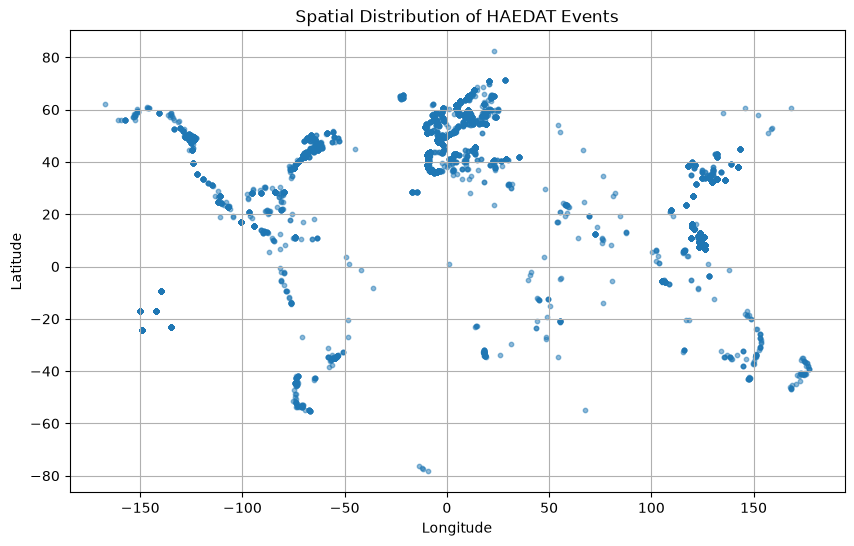

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(HAE_clean["Longitude"], HAE_clean["Latitude"], alpha=0.5, s=10)
plt.title("Spatial Distribution of HAEDAT Events")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

In [50]:
# Ensure Target_Date is parsed as datetime
HAE_clean["Target_Date"] = pd.to_datetime(HAE_clean["Target_Date"])

print("=" * 60)
print("HAEDAT CLEANED DATASET SANITY CHECK")
print("=" * 60)

# -------------------------------------------------------------------
# CHECK 1: Missing Values in Critical Columns
# -------------------------------------------------------------------
critical_cols = ["Latitude", "Longitude", "Target_Date"]
missing_counts = HAE_clean[critical_cols].isna().sum()

print("\n1. Missing Values Count:")
print(missing_counts)

if missing_counts.sum() == 0:
    print(" PASSED: No missing values in critical columns.")
else:
    print(" WARNING: Found missing values in critical columns!")

# -------------------------------------------------------------------
# CHECK 2: Geographic Coordinate Boundaries
# -------------------------------------------------------------------
valid_lat = HAE_clean["Latitude"].between(-90, 90).all()
valid_lon = HAE_clean["Longitude"].between(-180, 180).all()

print("\n2. Coordinate Validity:")
print(f"   Latitude range:  [{HAE_clean['Latitude'].min():.4f}, {HAE_clean['Latitude'].max():.4f}]")
print(f"   Longitude range: [{HAE_clean['Longitude'].min():.4f}, {HAE_clean['Longitude'].max():.4f}]")

if valid_lat and valid_lon:
    print("PASSED: All coordinates fall within valid physical limits (-90 to 90, -180 to 180).")
else:
    print(" WARNING: Found coordinates outside global physical boundaries!")

# Check for Null Island (0,0)
null_island_count = ((HAE_clean["Latitude"] == 0) & (HAE_clean["Longitude"] == 0)).sum()
if null_island_count == 0:
    print(" PASSED: No Null Island (0,0) placeholder coordinates found.")
else:
    print(f" WARNING: Found {null_island_count} entries at (0.0, 0.0).")

# -------------------------------------------------------------------
# CHECK 3: Date Range Boundaries
# -------------------------------------------------------------------
min_date = HAE_clean["Target_Date"].min()
max_date = HAE_clean["Target_Date"].max()

print("\n3. Temporal Range:")
print(f"   Earliest Event Date: {min_date.strftime('%Y-%m-%d')}")
print(f"   Latest Event Date:   {max_date.strftime('%Y-%m-%d')}")

# Copernicus reanalysis data generally covers 1993 to present
copernicus_start = pd.to_datetime("1993-01-01")
if min_date >= copernicus_start:
    print(" PASSED: All event dates fall within the Copernicus satellite record (1993+).")
else:
    pre_1993_count = (HAE_clean["Target_Date"] < copernicus_start).sum()
    print(f"NOTE: {pre_1993_count} events occurred before 1993 (may lack full Copernicus coverage).")

# -------------------------------------------------------------------
# SUMMARY 4: Copernicus API Download Estimates & Bounding Boxes
# -------------------------------------------------------------------
print("\n" + "=" * 60)
print(" COPERNICUS API BOUNDING BOX ESTIMATES")
print("=" * 60)

# Global bounding box for querying
min_lat, max_lat = HAE_clean["Latitude"].min(), HAE_clean["Latitude"].max()
min_lon, max_lon = HAE_clean["Longitude"].min(), HAE_clean["Longitude"].max()

print("\nGlobal Bounding Box for Copernicus Queries:")
print(f"   min_latitude  = {min_lat:.4f}")
print(f"   max_latitude  = {max_lat:.4f}")
print(f"   min_longitude = {min_lon:.4f}")
print(f"   max_longitude = {max_lon:.4f}")

# Sample per-event local bounding box buffer size (e.g., +/- 0.5 degrees)
buffer_deg = 0.5
print(f"\nLocal Event Buffer Recommendation (+/- {buffer_deg}° lat/lon):")
print(f"   Example Lat Range: [{HAE_clean['Latitude'].iloc[0] - buffer_deg:.4f}, {HAE_clean['Latitude'].iloc[0] + buffer_deg:.4f}]")
print(f"   Example Lon Range: [{HAE_clean['Longitude'].iloc[0] - buffer_deg:.4f}, {HAE_clean['Longitude'].iloc[0] + buffer_deg:.4f}]")

print("\n" + "=" * 60)
print(" SANITY CHECK COMPLETE")
print("=" * 60)

HAEDAT CLEANED DATASET SANITY CHECK

1. Missing Values Count:
Latitude       0
Longitude      0
Target_Date    0
dtype: int64
 PASSED: No missing values in critical columns.

2. Coordinate Validity:
   Latitude range:  [-78.3833, 82.2333]
   Longitude range: [-167.2800, 177.2889]
PASSED: All coordinates fall within valid physical limits (-90 to 90, -180 to 180).
 PASSED: No Null Island (0,0) placeholder coordinates found.

3. Temporal Range:
   Earliest Event Date: 1770-03-01
   Latest Event Date:   2026-06-01
NOTE: 543 events occurred before 1993 (may lack full Copernicus coverage).

 COPERNICUS API BOUNDING BOX ESTIMATES

Global Bounding Box for Copernicus Queries:
   min_latitude  = -78.3833
   max_latitude  = 82.2333
   min_longitude = -167.2800
   max_longitude = 177.2889

Local Event Buffer Recommendation (+/- 0.5° lat/lon):
   Example Lat Range: [57.7761, 58.7761]
   Example Lon Range: [5.0473, 6.0473]

 SANITY CHECK COMPLETE


**Statistics (Mayowa)**

In [51]:
#STATS
import numpy as np
import pandas as pd
import xarray as xr
import copernicusmarine
import matplotlib.pyplot as plt

In [52]:
# Copernicus global ocean physics reanalysis
PHYSICS_DATASET_ID = "cmems_mod_glo_phy_my_0.083deg_P1D-m"

# Start with temperature and salinity
PHYSICS_VARIABLES = [
    "thetao",  # Sea water temperature
    "so"       # Sea water salinity
]

# Use a 1-degree box around each event location
BUFFER_DEGREES = 1.0

# Copernicus data are daily, so allow a difference of up to one day
MAX_TIME_DIFFERENCE = pd.Timedelta(days=1)

In [53]:
physics_ds = copernicusmarine.open_dataset(
    dataset_id=PHYSICS_DATASET_ID,
    variables=PHYSICS_VARIABLES
)

physics_ds
list(physics_ds.data_vars)

INFO - 2026-09-24T21:18:38Z - Selected dataset version: "202311"
INFO - 2026-09-24T21:18:38Z - Selected dataset part: "default"


[np.str_('thetao'), np.str_('so')]